In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x)else x)

c:\Users\heroj\anaconda3\envs\proyecto_python1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_DS_ch = df[(df['job_country']== 'Chile') & (df['job_title_short'] == 'Data Scientist')].copy()

In [3]:
df_DS_ch = df_DS_ch.dropna(subset=['salary_year_avg'])

df_DS_ch_exploded = df_DS_ch.explode('job_skills')

df_DS_ch_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
22850,88128.0,python
22850,88128.0,sql
22850,88128.0,gcp
22850,88128.0,aws
22850,88128.0,power bi


In [4]:
df_DS_skills = df_DS_ch_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DS_skills = df_DS_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

ds_job_count = len(df_DS_ch)

df_DS_skills['skill_percent'] = df_DS_skills['skill_count'] / ds_job_count * 100

skill_percent = 5

df_DS_skills_demand = df_DS_skills[df_DS_skills['skill_percent'] > skill_percent]

df_DS_skills

,skill_count,median_salary,skill_percent
job_skills,,,
sql,4,104564.0,80.0
python,4,139250.0,80.0
r,3,157500.0,60.0
tableau,3,88128.0,60.0
aws,2,104564.0,40.0
gcp,2,104564.0,40.0
scikit-learn,2,139250.0,40.0
power bi,2,122814.0,40.0
alteryx,1,64800.0,20.0


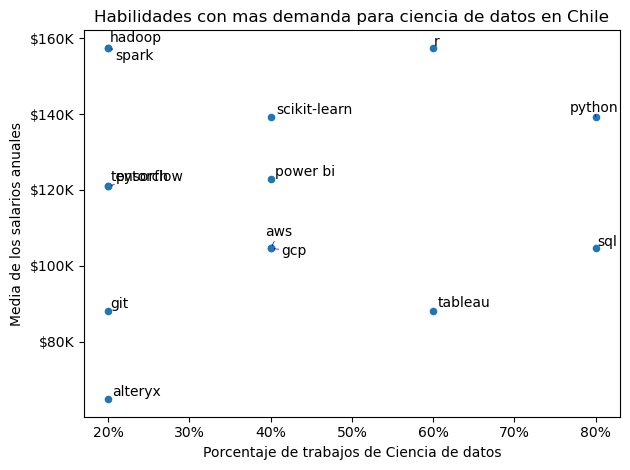

In [7]:
from adjustText import adjust_text


df_DS_skills_demand.plot(kind='scatter', x='skill_percent', y='median_salary')
texts = []

for i, txt in enumerate(df_DS_skills_demand.index):
    texts.append(plt.text(df_DS_skills_demand['skill_percent'].iloc[i], df_DS_skills_demand['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle="->", color='blue', lw=0.5))
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y , pos: f'${int(y/1000)}K'))
plt.xlabel('Porcentaje de trabajos de Ciencia de datos')
plt.ylabel('Media de los salarios anuales')
plt.title('Habilidades con mas demanda para ciencia de datos en Chile')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.tight_layout()
plt.show()
